In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [55]:
array = np.zeros((2,10))
array[1] = np.linspace(0,1,10)[0:20]
array[1]

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

In [2]:
def stationary_bootstrap(x):
    # repeat the data once for periodicity, and not choose data out of the range
    x_period = np.concatenate((x, x))

    x_final = np.array([])
    while True:
        L = int(np.random.exponential(scale=len(x), size=None))
        while L > len(x):
            L = int(np.random.exponential(scale=len(x), size=None))
            
        x_0 = np.random.randint(low=0, high=len(x))
        
        if len(x_final) + L < len(x):
            # choose L data points from x_period starting from x_0
            x_final = np.concatenate((x_final, x_period[x_0:x_0+L]))
        else:
            # fill the remaining data points
            x_final = np.concatenate((x_final, x_period[x_0:x_0+len(x)-len(x_final)]))
            return x_final

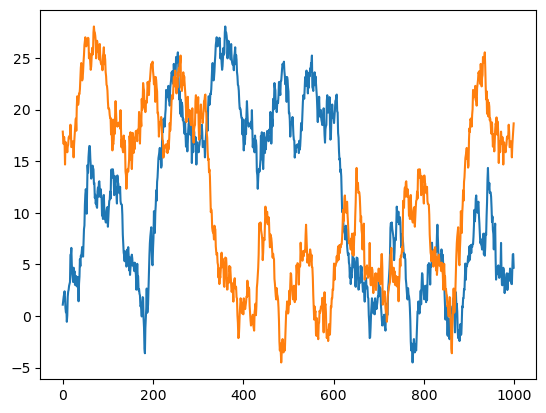

In [37]:
# y is a random walk
y = np.cumsum(np.random.normal(size=1000))

y_bootstrap = stationary_bootstrap(y)
plt.plot(y, label='Original Data')
plt.plot(y_bootstrap, label='Bootstrap Sample')